### Understanding the dataset


📊 DATASET STRUCTURE & DISTRIBUTION


--- TRAIN ---
bird: 1414 images
drone: 1248 images
Class imbalance: 11.74%

--- VALID ---
bird: 217 images
drone: 225 images
Class imbalance: 3.56%

--- TEST ---
bird: 121 images
drone: 94 images
Class imbalance: 22.31%


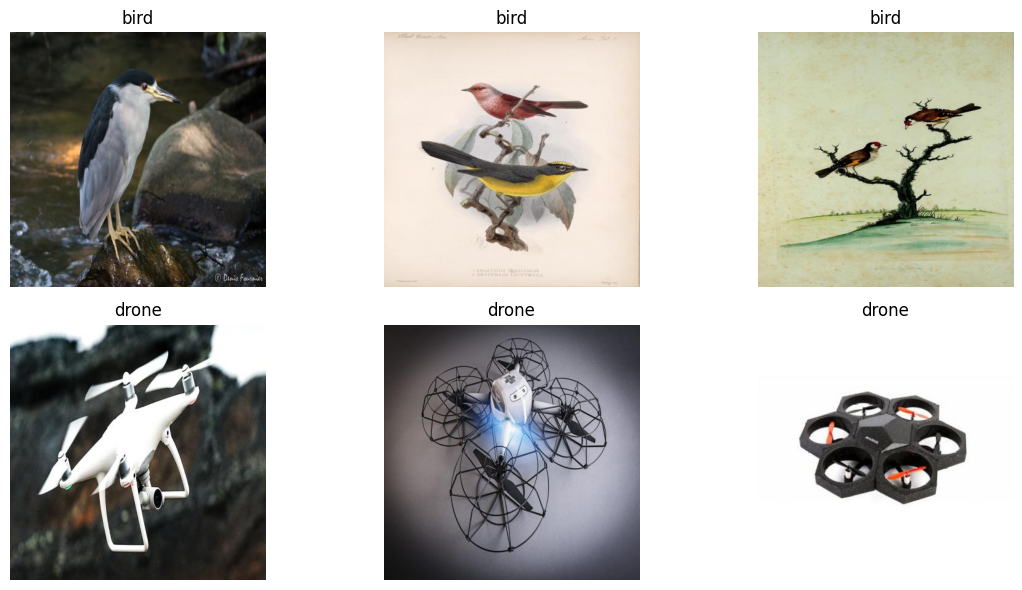

In [5]:
import os
import random
import matplotlib.pyplot as plt
from collections import defaultdict
from PIL import Image

DATA_DIR = r"C:\Vasu\Guvi\Aerial Object Classification and Detection\data"

def analyze_dataset():
    summary = defaultdict(dict)

    print("\n📊 DATASET STRUCTURE & DISTRIBUTION\n")

    for split in ['train', 'valid', 'test']:
        split_path = os.path.join(DATA_DIR, split)

        print(f"\n--- {split.upper()} ---")

        total_images = 0

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)

            if os.path.isdir(class_path):
                images = [
                    f for f in os.listdir(class_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                ]
                count = len(images)
                summary[split][class_name] = count
                total_images += count

                print(f"{class_name}: {count} images")

        # Calculate imbalance ratio
        if len(summary[split]) == 2:
            values = list(summary[split].values())
            diff = abs(values[0] - values[1])
            imbalance_percent = (diff / max(values)) * 100
            print(f"Class imbalance: {imbalance_percent:.2f}%")

    return summary


def visualize_samples(split='train', samples_per_class=3):
    split_path = os.path.join(DATA_DIR, split)

    plt.figure(figsize=(12, 6))

    i = 1
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]

            random_samples = random.sample(images, samples_per_class)

            for img_name in random_samples:
                img_path = os.path.join(class_path, img_name)
                img = Image.open(img_path)

                plt.subplot(2, samples_per_class, i)
                plt.imshow(img)
                plt.title(class_name)
                plt.axis("off")
                i += 1

    plt.tight_layout()
    plt.show()


# Run analysis
summary = analyze_dataset()

# Visualize training samples
visualize_samples('train', samples_per_class=3)

In [6]:
import os
from PIL import Image
import numpy as np

DATA_DIR = r"C:\Vasu\Guvi\Aerial Object Classification and Detection\data"

def analyze_image_sizes(split='train'):
    split_path = os.path.join(DATA_DIR, split)
    
    widths = []
    heights = []

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)
                    try:
                        with Image.open(img_path) as img:
                            w, h = img.size
                            widths.append(w)
                            heights.append(h)
                    except:
                        print(f"Corrupted image: {img_path}")

    print("\n📐 IMAGE SIZE ANALYSIS")
    print(f"Min Width: {min(widths)}")
    print(f"Max Width: {max(widths)}")
    print(f"Min Height: {min(heights)}")
    print(f"Max Height: {max(heights)}")
    print(f"Average Width: {int(np.mean(widths))}")
    print(f"Average Height: {int(np.mean(heights))}")

analyze_image_sizes('train')


📐 IMAGE SIZE ANALYSIS
Min Width: 416
Max Width: 416
Min Height: 416
Max Height: 416
Average Width: 416
Average Height: 416


## Data Preprocessing

In [13]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


DATA_DIR = r"C:\Vasu\Guvi\Aerial Object Classification and Detection\data"
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    
    # Random crop with slight zoom effect
    transforms.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0),   # zoom range
        ratio=(0.9, 1.1)
    ),
    
    # Horizontal flip (realistic)
    transforms.RandomHorizontalFlip(p=0.5),
    
    # Mild rotation
    transforms.RandomRotation(degrees=15),
    
    # Brightness & contrast variation
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [14]:
train_dataset = datasets.ImageFolder(
    root=f"{DATA_DIR}/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=f"{DATA_DIR}/valid",
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=f"{DATA_DIR}/test",
    transform=val_test_transforms
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [17]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


## Custon CNN

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Transfer Learning (ResNet)

In [19]:
from torchvision import models

def get_resnet_model():
    model = models.resnet18(weights="IMAGENET1K_V1")

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 1)
    )

    return model

## Training Pipeline

### Metrics Function

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }

### Training Function

In [21]:
import time
import copy

def train_model(model, train_loader, val_loader, epochs=15):

    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    patience = 3
    early_stop_counter = 0

    start_time = time.time()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss = 0
            all_preds = []
            all_labels = []

            for images, labels in loader:
                images = images.to(device)
                labels = labels.float().to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(images).squeeze()
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                preds = torch.sigmoid(outputs) > 0.5

                running_loss += loss.item() * images.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(loader.dataset)
            metrics = calculate_metrics(all_labels, all_preds)

            print(f"{phase} Loss: {epoch_loss:.4f} | F1: {metrics['f1']:.4f}")

            if phase == "val":
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(metrics["accuracy"])

                if metrics["f1"] > best_f1:
                    best_f1 = metrics["f1"]
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), "best_model.pth")
                    early_stop_counter = 0
                else:
                    early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

    total_time = time.time() - start_time
    model.load_state_dict(best_model_wts)

    return model, history, total_time

## EVALUATION

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images).squeeze()
            preds = torch.sigmoid(outputs) > 0.5

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## PLOT TRAINING CURVES

In [23]:
def plot_history(history):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history["val_loss"])
    plt.title("Validation Loss")

    plt.subplot(1,2,2)
    plt.plot(history["val_acc"])
    plt.title("Validation Accuracy")

    plt.show()

## MODEL COMPARISON

In [24]:
custom_model = CustomCNN()
custom_model, custom_hist, custom_time = train_model(custom_model, train_loader, val_loader)

resnet_model = get_resnet_model()
resnet_model, resnet_hist, resnet_time = train_model(resnet_model, train_loader, val_loader)


Epoch 1/15
train Loss: 2.1258 | F1: 0.6053
val Loss: 0.5089 | F1: 0.7347

Epoch 2/15
train Loss: 0.5465 | F1: 0.7004
val Loss: 0.4780 | F1: 0.7671

Epoch 3/15
train Loss: 0.5038 | F1: 0.7338
val Loss: 0.4177 | F1: 0.7915

Epoch 4/15
train Loss: 0.4649 | F1: 0.7621
val Loss: 0.4660 | F1: 0.8137

Epoch 5/15
train Loss: 0.4743 | F1: 0.7554
val Loss: 0.4317 | F1: 0.8034

Epoch 6/15
train Loss: 0.4445 | F1: 0.7716
val Loss: 0.4359 | F1: 0.8101

Epoch 7/15
train Loss: 0.4466 | F1: 0.7805
val Loss: 0.4118 | F1: 0.8216

Epoch 8/15
train Loss: 0.4241 | F1: 0.7841
val Loss: 0.4571 | F1: 0.8286

Epoch 9/15
train Loss: 0.4138 | F1: 0.7972
val Loss: 0.4509 | F1: 0.8094

Epoch 10/15
train Loss: 0.3938 | F1: 0.8084
val Loss: 0.3527 | F1: 0.8742

Epoch 11/15
train Loss: 0.3912 | F1: 0.8077
val Loss: 0.5667 | F1: 0.8238

Epoch 12/15
train Loss: 0.4007 | F1: 0.8155
val Loss: 0.3893 | F1: 0.8455

Epoch 13/15
train Loss: 0.3852 | F1: 0.8215
val Loss: 0.4021 | F1: 0.8224
Early stopping triggered
Downloadi

100.0%



Epoch 1/15
train Loss: 0.2781 | F1: 0.8809
val Loss: 0.1588 | F1: 0.9290

Epoch 2/15
train Loss: 0.1969 | F1: 0.9100
val Loss: 0.1273 | F1: 0.9563

Epoch 3/15
train Loss: 0.1665 | F1: 0.9257
val Loss: 0.1162 | F1: 0.9478

Epoch 4/15
train Loss: 0.1602 | F1: 0.9313
val Loss: 0.1227 | F1: 0.9519

Epoch 5/15
train Loss: 0.1397 | F1: 0.9447
val Loss: 0.1321 | F1: 0.9420
Early stopping triggered



Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       121
           1       0.97      0.93      0.95        94

    accuracy                           0.95       215
   macro avg       0.96      0.95      0.95       215
weighted avg       0.95      0.95      0.95       215



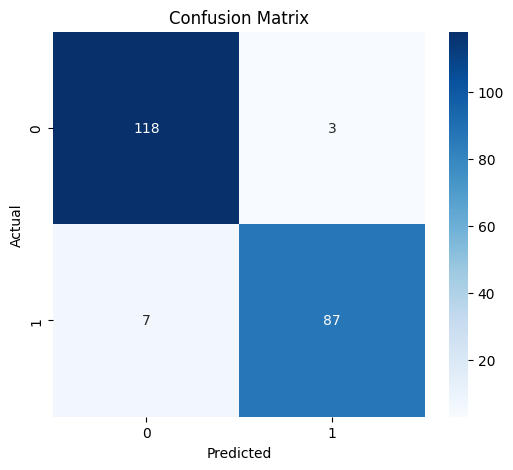

In [25]:
evaluate_model(resnet_model, test_loader)

In [26]:
torch.save(resnet_model.state_dict(), "bird_drone_resnet18.pth")